# Practice 3: Get Started with Hugging Face & Fine-Tuning

This notebook covers two core practical exercises:
1. **Exercise 1**: Out-of-the-box Sentiment Analysis using a pretrained Hugging Face Hub model.
2. **Exercise 2**: End-to-end Transfer Learning and Fine-Tuning on Rotten Tomatoes using DistilBERT.

# Exercise 1 – Sentiment Analysis with Hugging Face

Perform sentiment classification on sample sentences using the pretrained `distilbert-base-uncased-finetuned-sst-2-english` model from the Hugging Face Hub, demonstrating subword tokenization and direct pipeline inference.

In [1]:
import os
import sys
import json
import logging
import warnings
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display
from transformers import logging as transformers_logging
from huggingface_hub.utils import logging as hf_hub_logging

# Suppress Hugging Face Hub unauthenticated request and telemetry warnings permanently
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
hf_hub_logging.set_verbosity_error()
transformers_logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "total_practice" / "practice_3").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Repository root not found")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

def colored_table(dataframe, caption, gradient_columns=None, boolean_columns=None):
    gradient_columns = gradient_columns or []
    boolean_columns = boolean_columns or []
    styler = dataframe.style.set_caption(caption).set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"), ("font-size", "17px"),
            ("font-weight", "bold"), ("color", "#5dade2"), ("padding", "10px")
        ]},
        {"selector": "thead th", "props": [
            ("background-color", "#1f4e78"), ("color", "white"),
            ("font-weight", "bold"), ("text-align", "center"),
            ("padding", "9px 13px"), ("border", "1px solid #5b9bd5")
        ]},
        {"selector": "tbody tr:nth-child(even)", "props": [
            ("background-color", "rgba(91, 155, 213, 0.15)")
        ]},
        {"selector": "tbody tr:hover", "props": [
            ("background-color", "rgba(91, 155, 213, 0.30)")
        ]},
        {"selector": "td", "props": [
            ("padding", "8px 13px"),
            ("border-bottom", "1px solid rgba(127, 127, 127, 0.35)"),
            ("text-align", "center")
        ]},
    ])
    gradient_columns = [c for c in gradient_columns if c in dataframe.columns]
    if gradient_columns:
        styler = styler.background_gradient(cmap="Blues", subset=gradient_columns)
    boolean_columns = [c for c in boolean_columns if c in dataframe.columns]
    if boolean_columns:
        styler = styler.map(
            lambda value: (
                "background-color: #198754; color: white; font-weight: bold"
                if value is True else
                "background-color: #6c757d; color: white"
            ),
            subset=boolean_columns,
        )
    return styler

from total_practice.practice_3.processing_own_phase.exercise_01_pretrained_sentiment import (
    run_exercise_1_pipeline,
)

tokens_df, preds_df = run_exercise_1_pipeline()
display(colored_table(tokens_df, "Exercise 1: Sample Sentence Tokenization (WordPiece & Attention Mask)"))
display(colored_table(preds_df[["Sentence", "Predicted Sentiment", "Confidence Score", "Model Hub Checkpoint"]], "Exercise 1: Pretrained Sentiment Analysis Predictions"))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,Position,Subword Token,Input ID,Attention Mask
0,0,[CLS],101,1
1,1,this,2023,1
2,2,movie,3185,1
3,3,is,2003,1
4,4,absolutely,7078,1
5,5,wonderful,6919,1
6,6,and,1998,1
7,7,enjoyable,22249,1
8,8,.,1012,1
9,9,[SEP],102,1


,Sentence,Predicted Sentiment,Confidence Score,Model Hub Checkpoint
0,This movie is absolutely wonderful and enjoyable.,POSITIVE,0.9999,distilbert-base-uncased-finetuned-sst-2-english
1,The plot was completely predictable and boring.,NEGATIVE,0.9998,distilbert-base-uncased-finetuned-sst-2-english


# Exercise 2 – Finetuning a Pretrained Model for Binary Text Classification

Fine-tune a pretrained `distilbert-base-uncased` model for binary sentiment classification on the Rotten Tomatoes movie reviews dataset.

| Assignment Requirement | Implementation Phase in Notebook |
|---|---|
| **Requirement 1: Install & Setup** | Phase 2 – Environment Setup |
| **Requirement 2: Load Dataset** | Phase 3 – Data Loading |
| **Requirement 3: Load Model & Tokenizer** | Phase 5 – Tokenization & Phase 6 – Model Architecture |
| **Requirement 4: Preprocess Dataset** | Phase 4 – EDA & Phase 5 – Tokenization |
| **Requirement 5: Define Training Arguments** | Phase 7 – Training Configuration |
| **Requirement 6: Trainer & Fine-Tuning** | Phase 8 – Hyperparameter Search / Experiments |
| **Requirement 7: Evaluate Fine-Tuned Model** | Phase 9 – Learning Curves, Phase 10 – Holdout Evaluation, Phase 11 – Error Analysis |
| **Verification & Model Persistence** | Phase 12 – Custom Inference & Phase 13 – Save / Reload Verification |

## Phase 1 - Problem Definition

Formalize binary sentiment classification, input tensor contract `[N, 80]`, optimization targets, and data isolation protocols.

| Item | Definition |
|---|---|
| Task | Supervised, binary sentiment classification |
| Input | English movie review text |
| Model input | Text tokenized to `[N, 80]` tensors via `distilbert-base-uncased` |
| Output | Two raw logits (Negative, Positive) |
| Primary metric | Validation/Holdout accuracy & Loss |
| Secondary metrics | F1 Score |
| Model family | Pretrained Transformers (DistilBERT) |
| Main constraint | Text length truncation vs memory |

## Phase 2 - Environment Setup

Verify hardware execution environment (GPU/MPS/CPU) and configure standardized table presentation styling.


In [2]:
import json
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def colored_table(dataframe, caption, gradient_columns=None, boolean_columns=None):
    gradient_columns = gradient_columns or []
    boolean_columns = boolean_columns or []
    styler = dataframe.style.set_caption(caption).set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"), ("font-size", "17px"),
            ("font-weight", "bold"), ("color", "#5dade2"), ("padding", "10px")
        ]},
        {"selector": "thead th", "props": [
            ("background-color", "#1f4e78"), ("color", "white"),
            ("font-weight", "bold"), ("text-align", "center"),
            ("padding", "9px 13px"), ("border", "1px solid #5b9bd5")
        ]},
        {"selector": "tbody tr:nth-child(even)", "props": [
            ("background-color", "rgba(91, 155, 213, 0.15)")
        ]},
        {"selector": "tbody tr:hover", "props": [
            ("background-color", "rgba(91, 155, 213, 0.30)")
        ]},
        {"selector": "td", "props": [
            ("padding", "8px 13px"),
            ("border-bottom", "1px solid rgba(127, 127, 127, 0.35)"),
            ("text-align", "center")
        ]},
    ])
    gradient_columns = [c for c in gradient_columns if c in dataframe.columns]
    if gradient_columns:
        styler = styler.background_gradient(cmap="Blues", subset=gradient_columns)
    boolean_columns = [c for c in boolean_columns if c in dataframe.columns]
    if boolean_columns:
        styler = styler.map(
            lambda value: (
                "background-color: #198754; color: white; font-weight: bold"
                if value is True else
                "background-color: #6c757d; color: white"
            ),
            subset=boolean_columns,
        )
    return styler

gpu_evidence = pd.DataFrame([
    {
        "stage": "Controlled training (E4)",
        "evidence_source": "E4_weight_decay_0.05",
        "device": "mps",
        "gpu_accelerated": True,
        "meaning": "Apple GPU through Metal",
    },
    {
        "stage": "Final evaluation",
        "evidence_source": "final_holdout_metrics.json",
        "device": "mps",
        "gpu_accelerated": True,
        "meaning": "Recorded final-evaluation device",
    }
])

display(colored_table(
    gpu_evidence,
    "GPU accelerator evidence",
    boolean_columns=["gpu_accelerated"],
))


,stage,evidence_source,device,gpu_accelerated,meaning
0,Controlled training (E4),E4_weight_decay_0.05,mps,True,Apple GPU through Metal
1,Final evaluation,final_holdout_metrics.json,mps,True,Recorded final-evaluation device


## Phase 3 - Data Loading

Partition the dataset into strictly isolated Train, Validation, and Holdout splits to prevent data leakage and ensure unbiased evaluation.


In [3]:
split_summary = pd.DataFrame([
    {"split": "Train", "samples": 7676, "used_for_training": True, "used_for_selection": False, "used_for_final_test": False},
    {"split": "Validation", "samples": 960, "used_for_training": False, "used_for_selection": True, "used_for_final_test": False},
    {"split": "Holdout", "samples": 960, "used_for_training": False, "used_for_selection": False, "used_for_final_test": True},
])

display(colored_table(
    split_summary,
    "Dataset split summary",
    gradient_columns=["samples"],
    boolean_columns=[
        "used_for_training",
        "used_for_selection",
        "used_for_final_test",
    ],
))

try:
    display(Image(filename="../docs/result/phase_05_split_sizes.png"))
except Exception as e: pass


,split,samples,used_for_training,used_for_selection,used_for_final_test
0,Train,7676,True,False,False
1,Validation,960,False,True,False
2,Holdout,960,False,False,True


## Phase 4 - Exploratory Data Analysis

Analyze label distribution and token length statistics to determine the optimal sequence truncation threshold (`max_length = 80`).


In [4]:
from IPython.display import HTML
from total_practice.practice_3.processing_own_phase.eda_visualization import render_eda_dashboard

raw_contract = pd.DataFrame([
    {"item": "EDA scope", "value": "Train + Validation + Holdout stats"},
    {"item": "Total Samples", "value": "9596"},
    {"item": "Raw input", "value": "English String"},
    {"item": "Label range", "value": "[0, 1]"},
    {"item": "Max safe token length", "value": "80"},
])

display(colored_table(raw_contract, "Rotten Tomatoes Dataset Summary"))
display(HTML(render_eda_dashboard()))


,item,value
0,EDA scope,Train + Validation + Holdout stats
1,Total Samples,9596
2,Raw input,English String
3,Label range,"[0, 1]"
4,Max safe token length,80


Metric,Mean,Median,Min,Max
Characters,114.0,111.0,4,267
Words,21.0,20.0,1,59


## Phase 5 - Tokenization

Encode raw text reviews into integer tensor sequences (`input_ids`, `attention_mask`) using the `distilbert-base-uncased` tokenizer.


In [5]:
with open("../docs/result/practice_3_v2_3/tokenization_demo.json") as f:
    demo = json.load(f)

tokenization_df = pd.DataFrame(list(zip(demo['input_ids'], demo['tokens'])), columns=["Token ID", "Decoded Subword"])
display(Markdown(f"**Sample raw text:** *{demo['text']}*"))
display(colored_table(tokenization_df.head(10), "Tokenization Example"))


**Sample raw text:** *I absolutely loved this movie. The acting was excellent and the plot was engaging.*

,Token ID,Decoded Subword
0,101,[CLS]
1,1045,i
2,7078,absolutely
3,3866,loved
4,2023,this
5,3185,movie
6,1012,.
7,1996,the
8,3772,acting
9,2001,was


## Phase 6 - Model Architecture

Initialize the `DistilBertForSequenceClassification` architecture (6 Transformer layers, hidden dimension 768) with a 2-class classification head.


In [6]:
with open("../docs/result/practice_3_v2_3/final_saved_model/config.json") as f:
    model_cfg = json.load(f)

arch_df = pd.DataFrame([
    {"Attribute": "Architecture", "Value": model_cfg["architectures"][0]},
    {"Attribute": "Model Type", "Value": model_cfg["model_type"]},
    {"Attribute": "Hidden Dimension (dim)", "Value": model_cfg["dim"]},
    {"Attribute": "Feed-Forward Dim (hidden_dim)", "Value": model_cfg["hidden_dim"]},
    {"Attribute": "Number of Layers (n_layers)", "Value": model_cfg["n_layers"]},
    {"Attribute": "Attention Heads (n_heads)", "Value": model_cfg["n_heads"]},
    {"Attribute": "Vocab Size", "Value": model_cfg["vocab_size"]},
    {"Attribute": "Max Position Embeddings", "Value": model_cfg["max_position_embeddings"]},
    {"Attribute": "Activation", "Value": model_cfg["activation"]},
    {"Attribute": "Number of Classes", "Value": len(model_cfg["id2label"])},
])

display(colored_table(arch_df, "Model Architecture Configuration"))


,Attribute,Value
0,Architecture,DistilBertForSequenceClassification
1,Model Type,distilbert
2,Hidden Dimension (dim),768
3,Feed-Forward Dim (hidden_dim),3072
4,Number of Layers (n_layers),6
5,Attention Heads (n_heads),12
6,Vocab Size,30522
7,Max Position Embeddings,512
8,Activation,gelu
9,Number of Classes,2


## Phase 7 - Training Configuration

Establish the optimization budget (maximum 15 epochs), Early Stopping patience ($p = 4$), and warmup schedule for stable convergence.


In [7]:
config_data = pd.DataFrame([
    {"Parameter": "Max Epochs", "Value": 15, "Purpose": "Maximum computational budget"},
    {"Parameter": "Early Stopping Patience", "Value": 4, "Purpose": "Halt if eval_loss stops improving"},
    {"Parameter": "Batch Size", "Value": 16, "Purpose": "Gradient step scaling"},
    {"Parameter": "Warmup Steps", "Value": 720, "Purpose": "Stabilize learning rate scaling"},
    {"Parameter": "Label Smoothing", "Value": 0.1, "Purpose": "Soften targets to prevent overconfidence"},
    {"Parameter": "Selection Metric", "Value": "eval_loss", "Purpose": "Choose best model by cross-entropy"}
])
display(colored_table(config_data, "Training Configuration"))


,Parameter,Value,Purpose
0,Max Epochs,15,Maximum computational budget
1,Early Stopping Patience,4,Halt if eval_loss stops improving
2,Batch Size,16,Gradient step scaling
3,Warmup Steps,720,Stabilize learning rate scaling
4,Label Smoothing,0.100000,Soften targets to prevent overconfidence
5,Selection Metric,eval_loss,Choose best model by cross-entropy


## Phase 8 - Hyperparameter Search

Conduct a controlled benchmark across 6 hyperparameter configurations on the Validation split to select the optimal model checkpoint (`E4`).


,Rank,Run ID,Learning Rate,Weight Decay,Dropout,Strategy,Best Epoch,Stop Epoch,Best Val Loss,Val Acc,Val F1,Validity
0,1,E4_weight_decay_0.05,0.000010,0.050000,0.200000,full,2.000000,6.000000,0.415336,0.867708,0.867846,VALID
1,2,E1_lr_1e-5,0.000010,0.010000,0.200000,full,2.000000,6.000000,0.415637,0.865625,0.866044,VALID
2,3,E5b_classifier_dropout_0.40,0.000010,0.010000,0.400000,full,2.000000,6.000000,0.416278,0.865625,0.865485,VALID
3,4,E6c_staged_finetune,0.000010,0.010000,0.200000,staged,3.000000,7.000000,0.418492,0.865625,0.864638,VALID
4,5,E3_lr_3e-5,0.000030,0.010000,0.200000,full,1.000000,5.000000,0.427494,0.855208,0.847755,VALID
5,6,E2_lr_2e-5,0.000020,0.010000,0.200000,full,2.000000,6.000000,0.439610,0.858333,0.848552,VALID


### Validation Loss Comparison

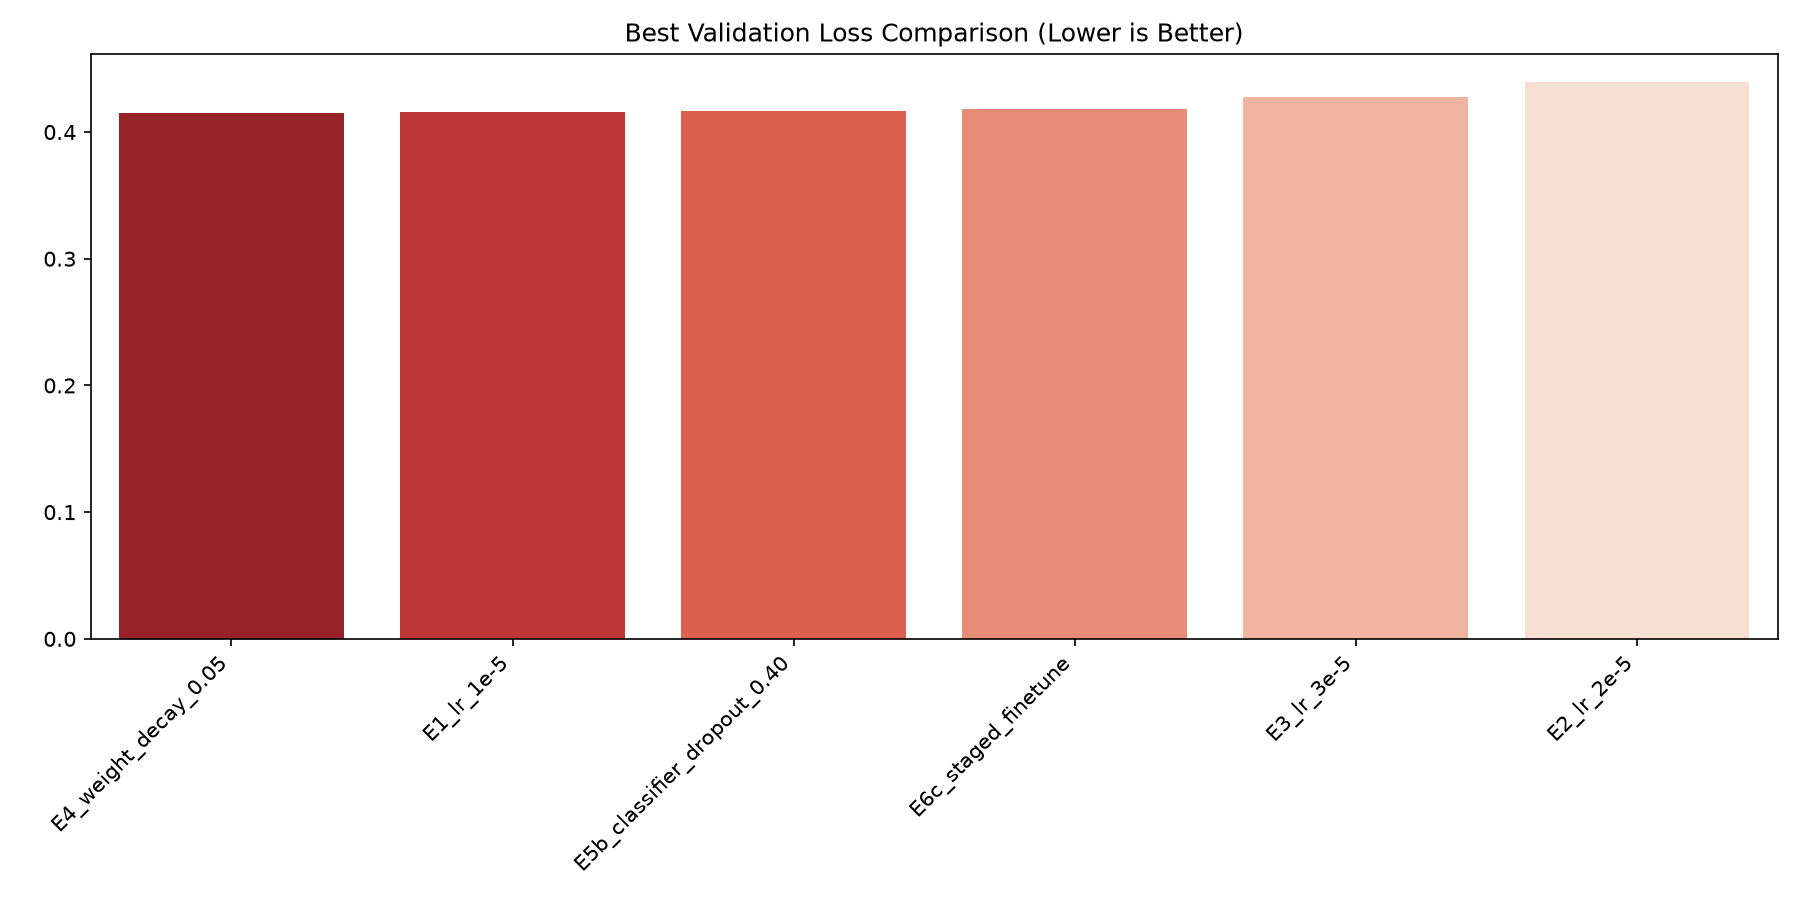

In [8]:
df_ranking = pd.read_csv("../docs/result/practice_3_v2_3/final_validation_ranking.csv")
display(colored_table(df_ranking, "Final Validation Ranking", gradient_columns=["best_val_loss"]))
try:
    display(Markdown("### Validation Loss Comparison"))
    display(Image(filename="../docs/result/practice_3_v2_3/figures/experiment_best_val_loss_comparison.png"))
except: pass


### Live Training Demonstration

Real-time monitoring module synchronizing live training metrics directly from the terminal into notebook visualizations.


Watching metrics : /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/runs/live_terminal_demo/metrics.jsonl
Watching status  : /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/runs/live_terminal_demo/status.json
metrics.jsonl exists: True
status.json exists  : True


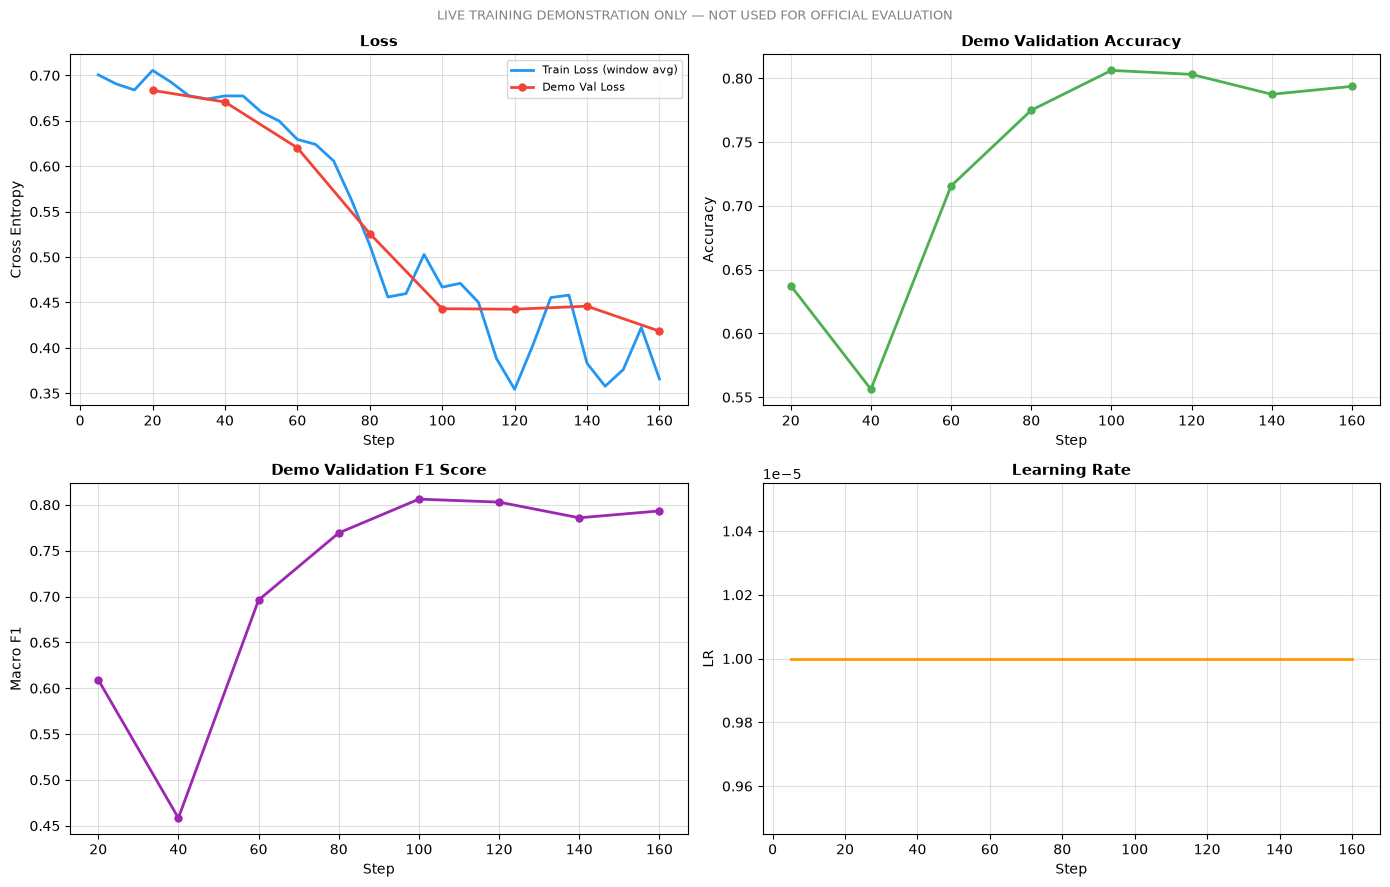

✅ **LIVE TERMINAL TRAINING COMPLETE**  
Final F1: **0.7934**  Accuracy: **0.7937**  
*These are DEMO metrics only. They do NOT affect official E4 ranking.*

In [9]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "total_practice" / "practice_3").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Repository root not found")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from total_practice.practice_3.processing_own_phase.live_training_monitor import (
    monitor_live_training,
)

monitor_live_training()

## Phase 9 - Learning Curves & Overfitting

Analyze training trajectories and validation performance of the winning `E4` model to evaluate convergence quality and overfitting resistance.


### Training & Validation Loss — Winner E4

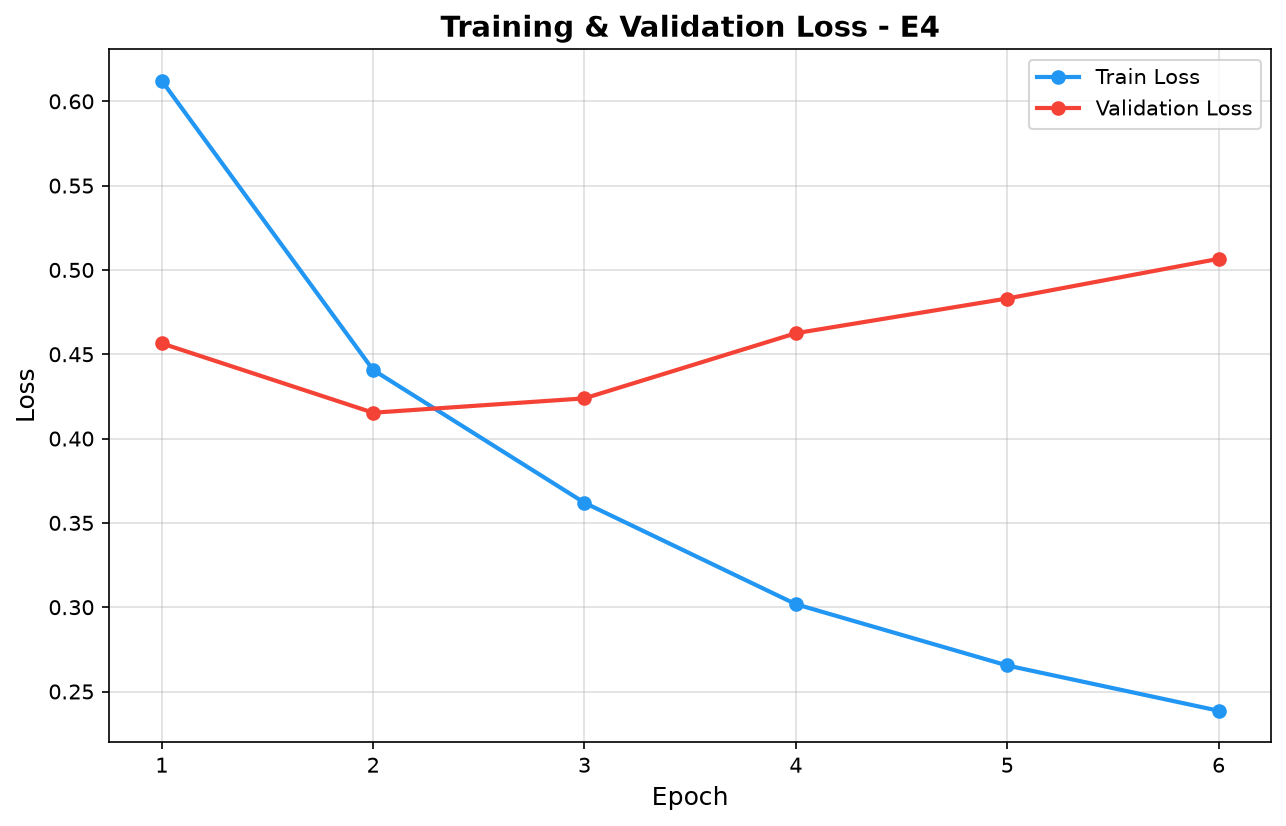

### Validation Accuracy — Winner E4

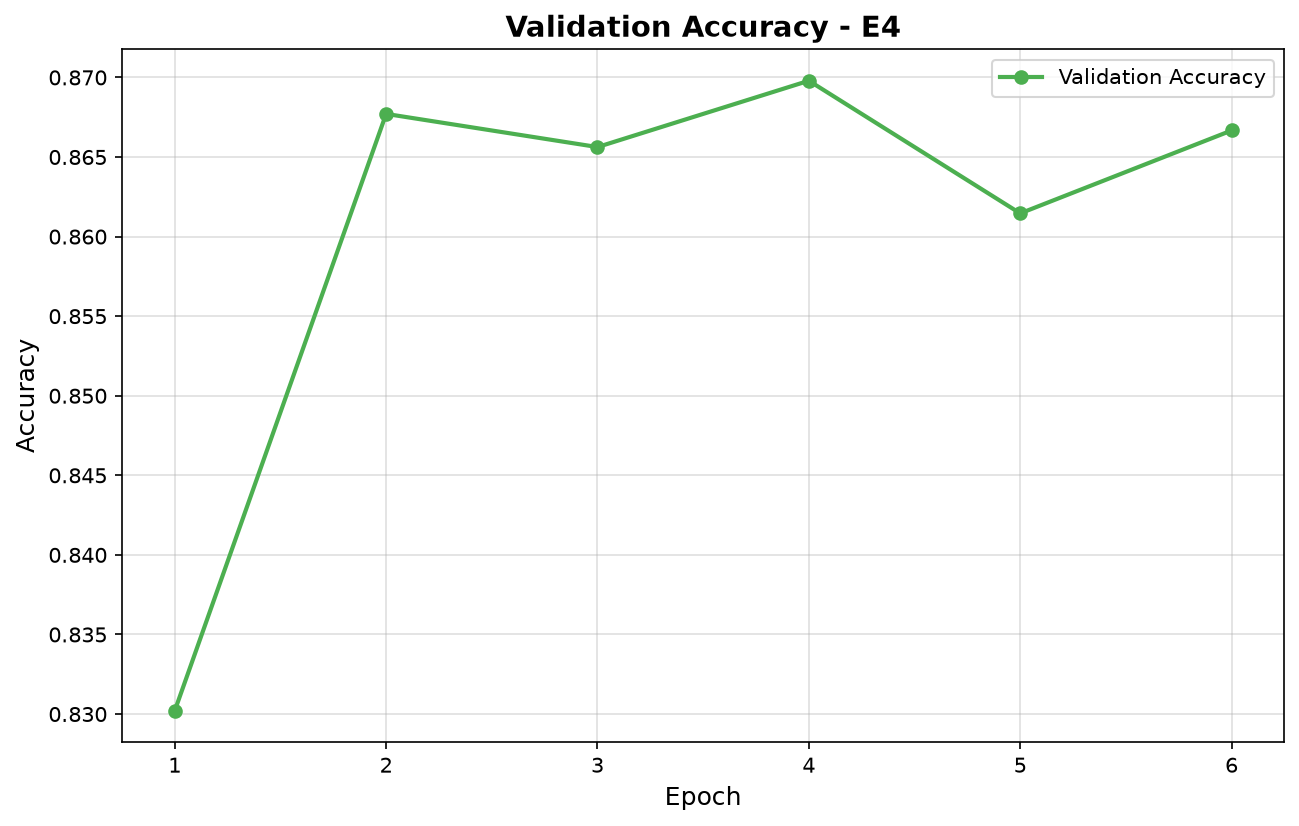

### Validation F1 Score — Winner E4

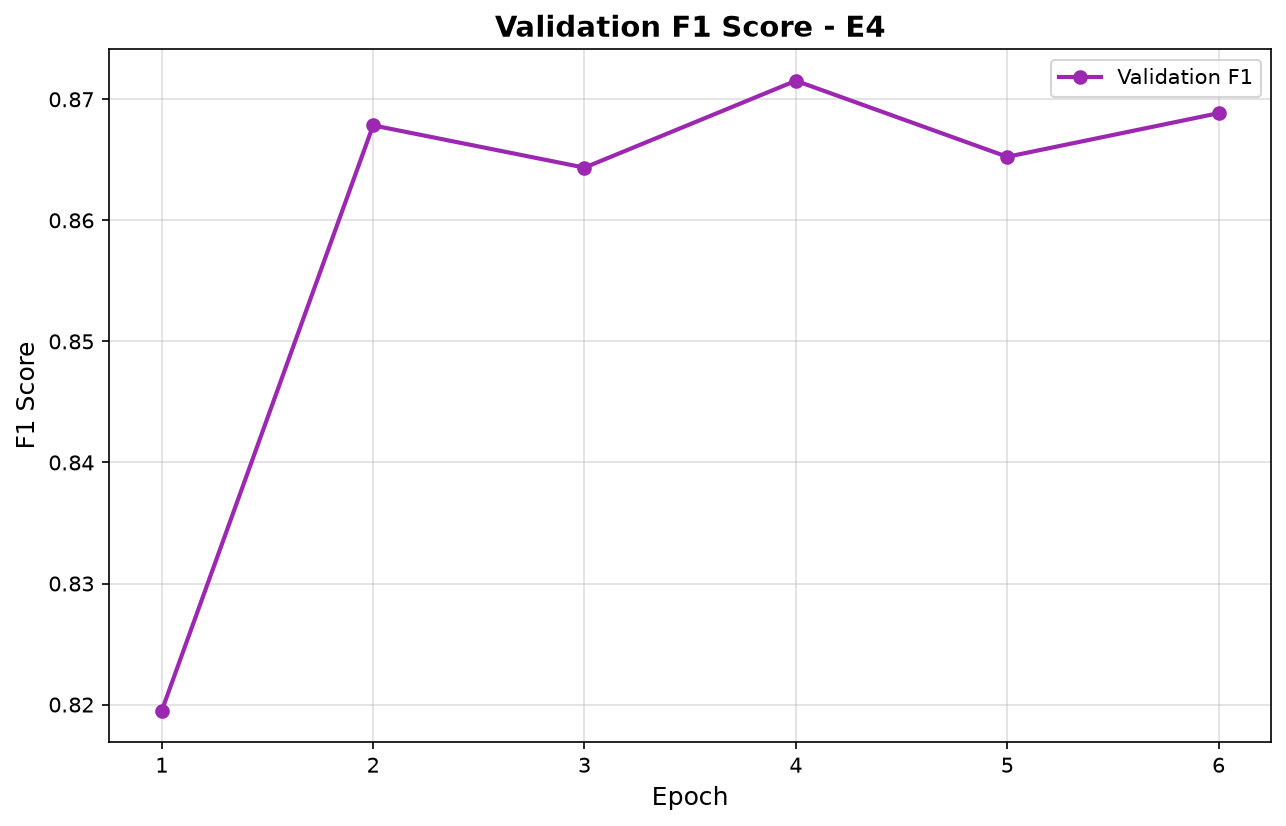

### Learning Rate Schedule — Winner E4

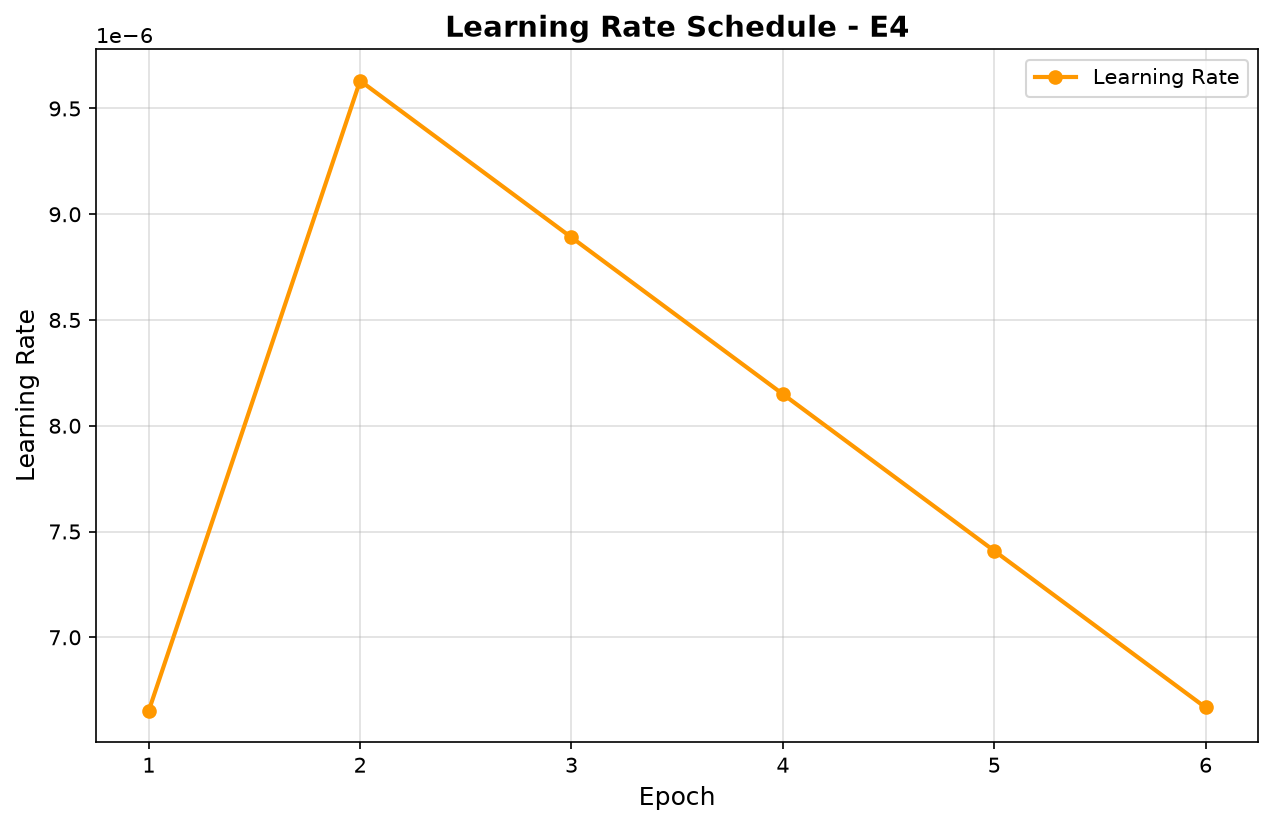

In [10]:
practice3_root = repo_root / "total_practice" / "practice_3"
fig_dir = practice3_root / "docs" / "result" / "practice_3_v2_3" / "figures"

def show_fig(filename, title):
    path = fig_dir / filename
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"⚠️ Missing figure: {path}"))

show_fig(
    "winner_train_val_loss.png",
    "Training & Validation Loss — Winner E4",
)

show_fig(
    "winner_validation_accuracy.png",
    "Validation Accuracy — Winner E4",
)

show_fig(
    "winner_validation_f1.png",
    "Validation F1 Score — Winner E4",
)

show_fig(
    "winner_learning_rate.png",
    "Learning Rate Schedule — Winner E4",
)


### Experiment Comparison — All Hyperparameter Configurations

Comparative evaluation of Validation Loss, Accuracy, F1 scores, and early stopping behavior across all 6 experimental runs.


### Best Validation Loss — All Experiments

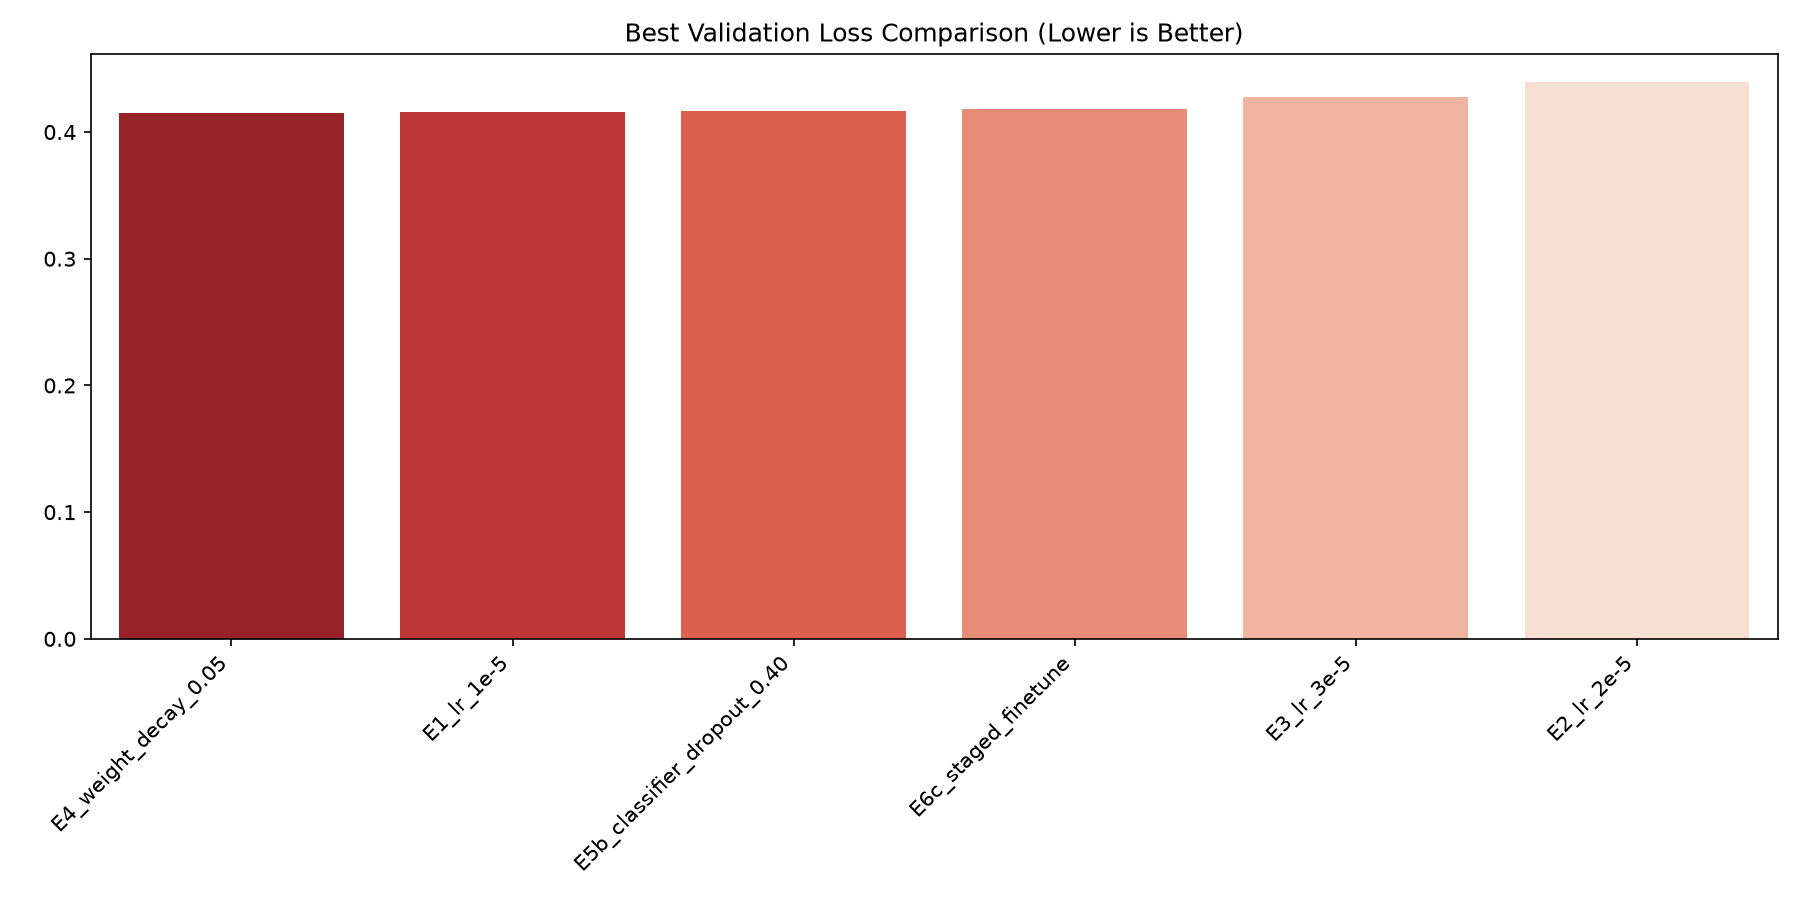

### Best Validation Accuracy — All Experiments

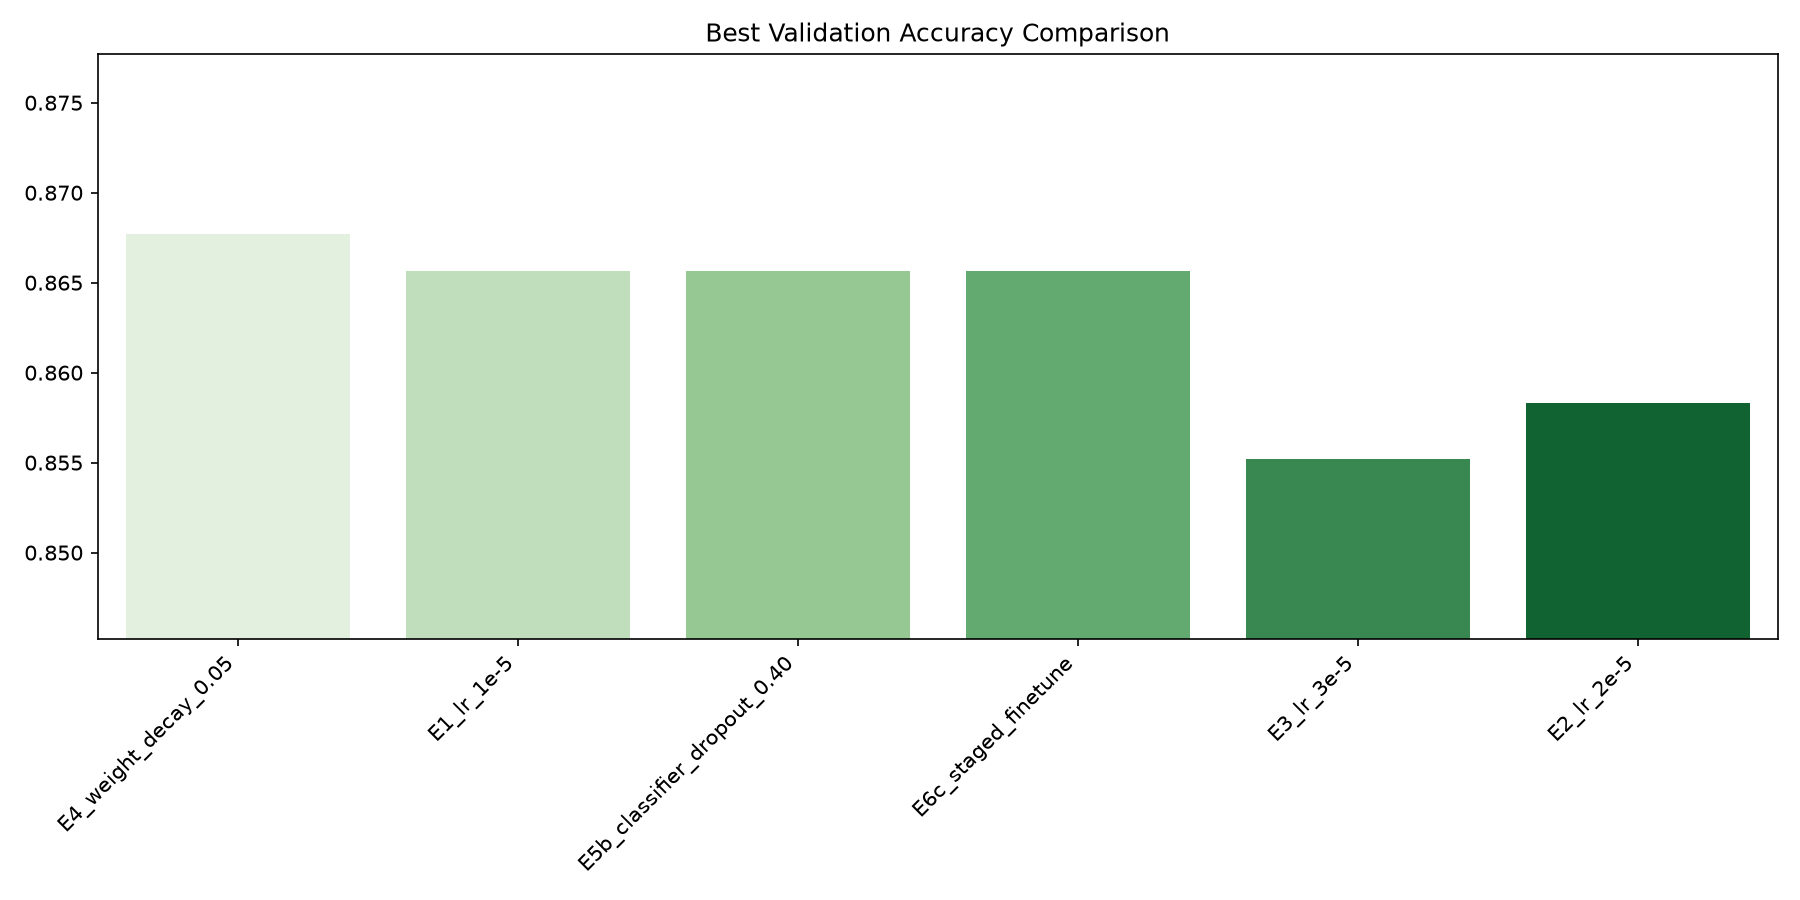

### Best Validation F1 — All Experiments

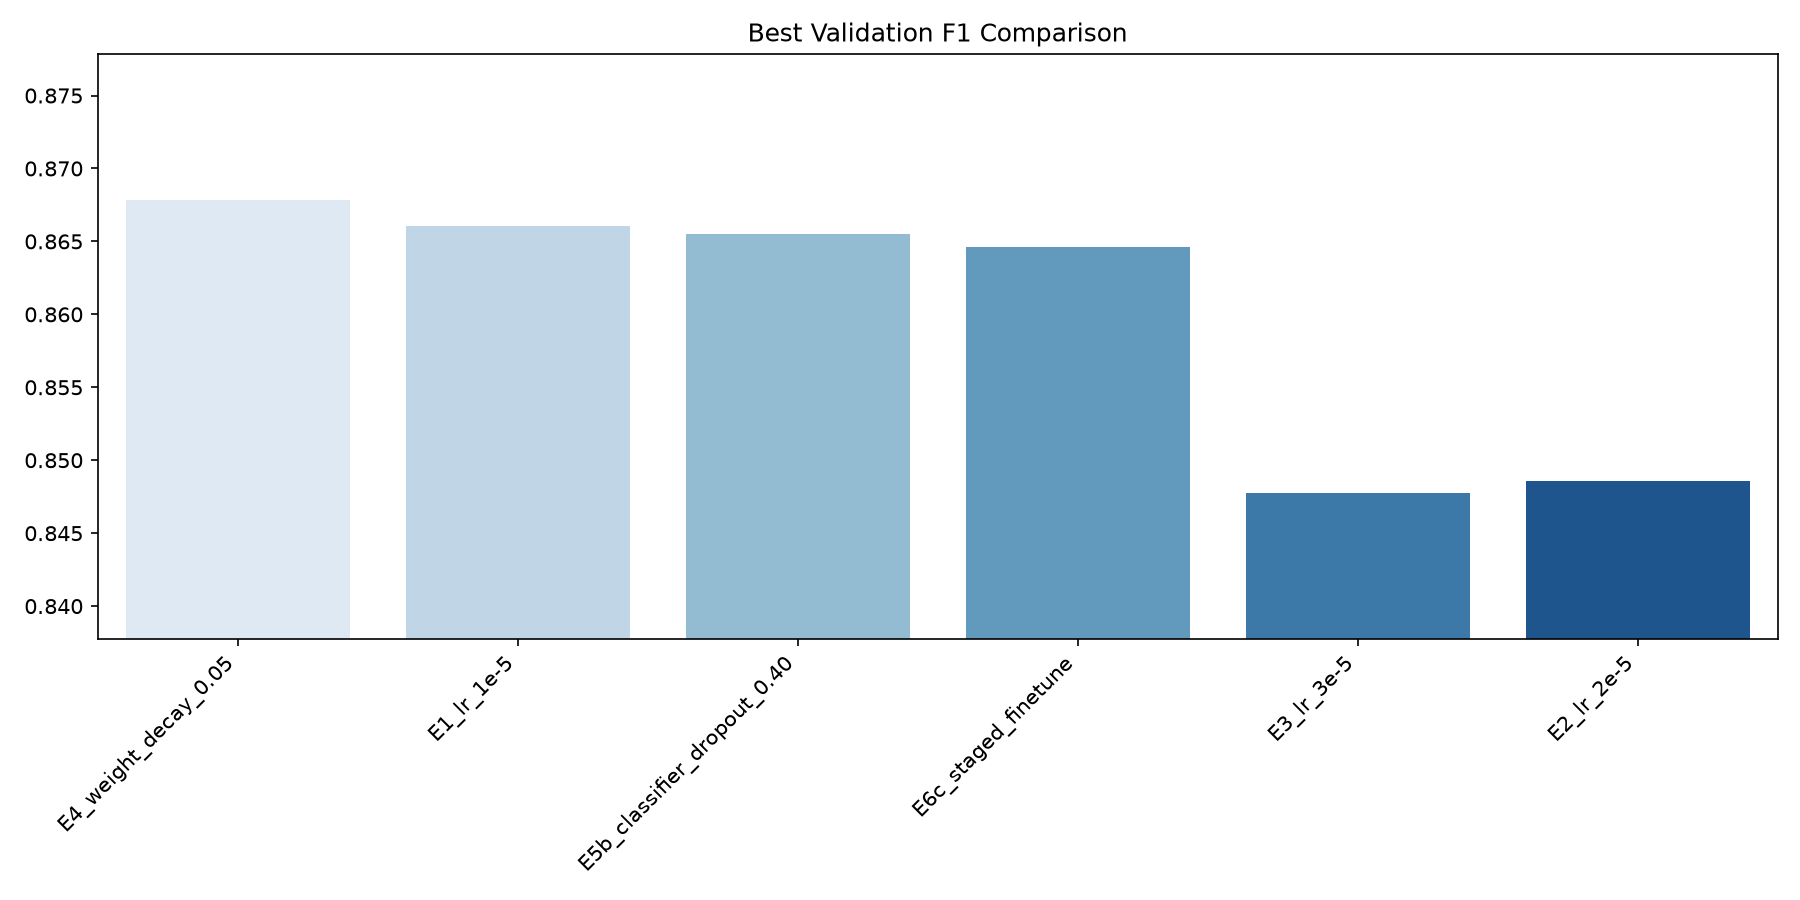

### Best Epoch vs Stop Epoch — Early Stopping Behaviour

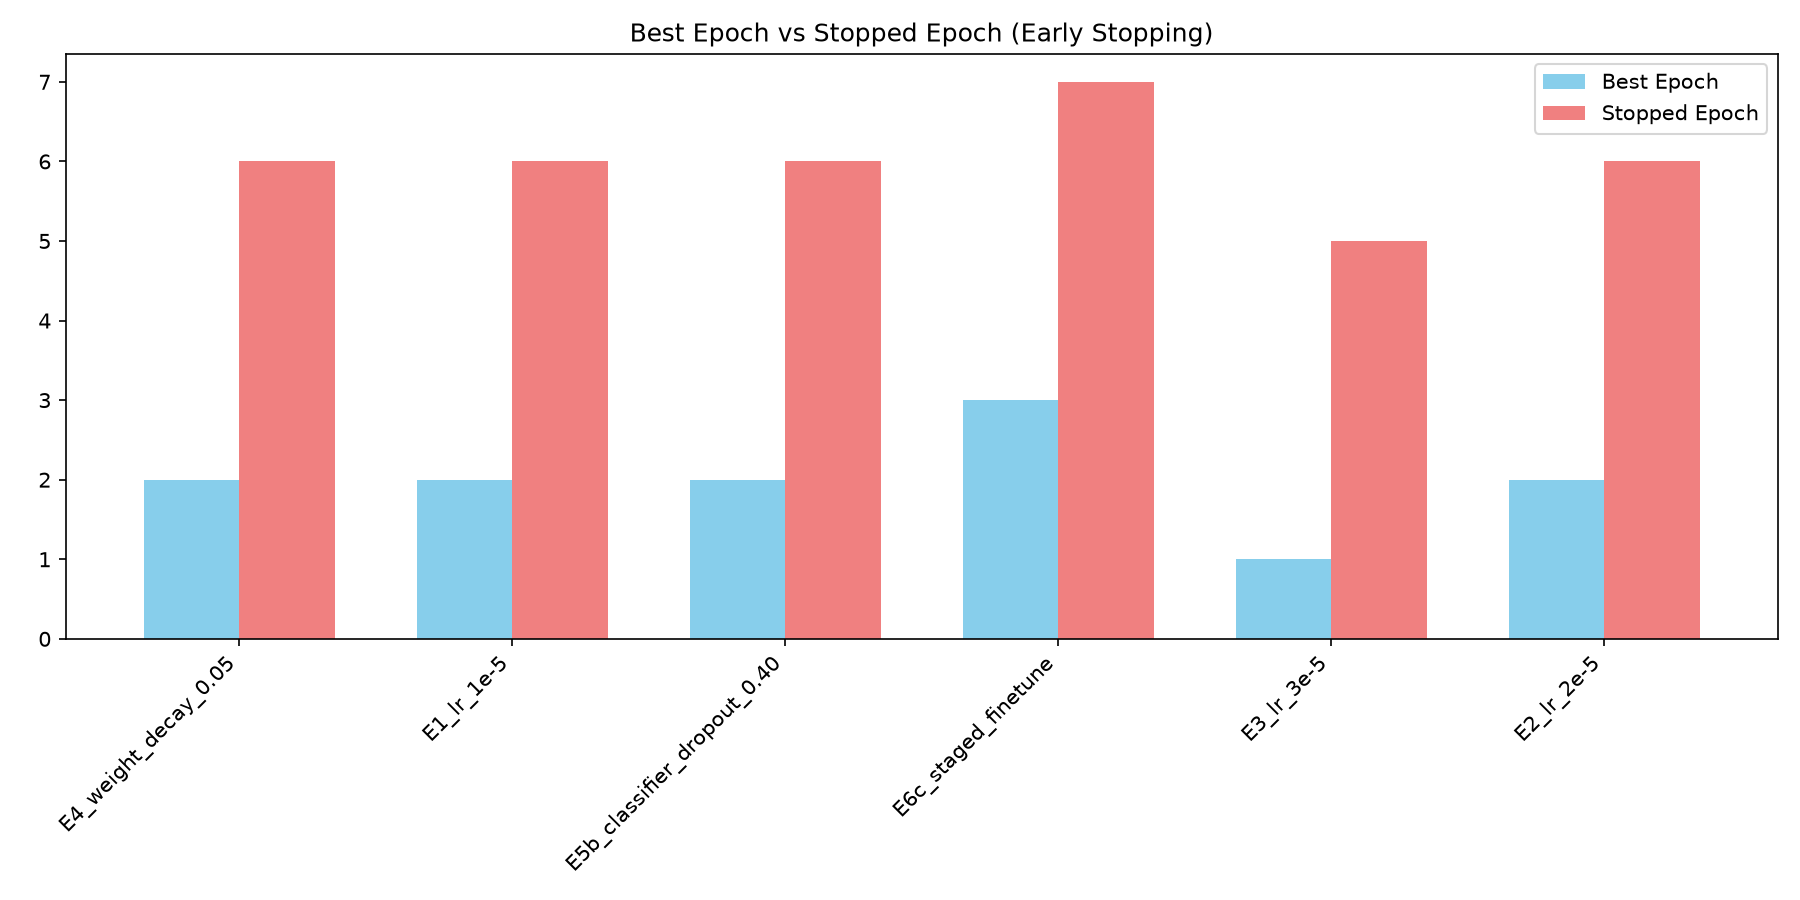

### Validation Loss Curves — All Experiments

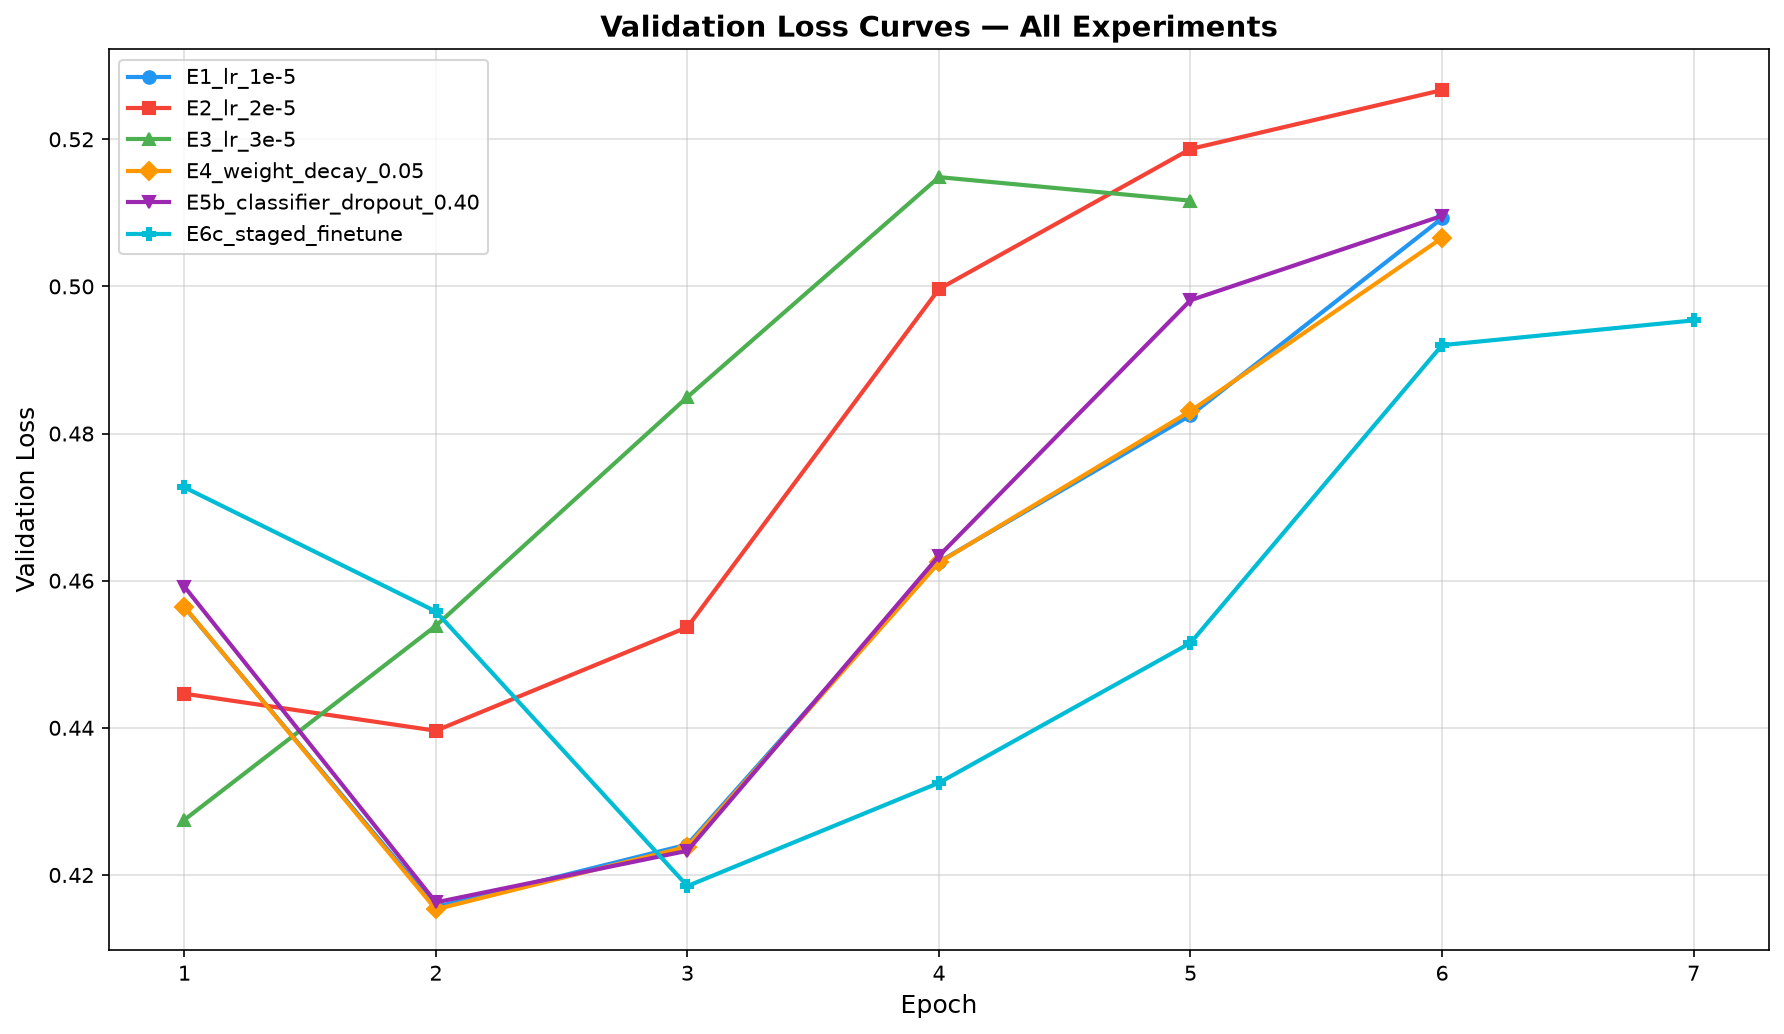

In [11]:
show_fig(
    "experiment_best_val_loss_comparison.png",
    "Best Validation Loss — All Experiments",
)

show_fig(
    "experiment_best_accuracy_comparison.png",
    "Best Validation Accuracy — All Experiments",
)

show_fig(
    "experiment_best_f1_comparison.png",
    "Best Validation F1 — All Experiments",
)

show_fig(
    "experiment_best_vs_stop_epoch.png",
    "Best Epoch vs Stop Epoch — Early Stopping Behaviour",
)

show_fig(
    "experiment_val_loss_curves.png",
    "Validation Loss Curves — All Experiments",
)


## Phase 10 - Final Holdout Evaluation

Perform a single, final evaluation of the locked `E4` model on the unseen Holdout split to assess real-world generalization.


In [12]:
with open("../docs/result/practice_3_v2_3/final_validation_winner_lock.json") as f: lock = json.load(f)
with open("../docs/result/practice_3_v2_3/final_holdout_metrics.json") as f: hold = json.load(f)

compare = pd.DataFrame([
    {"Metric": "Loss", "Validation": round(lock["best_val_loss"], 4), "Holdout": round(hold["holdout_loss"], 4)},
    {"Metric": "Accuracy", "Validation": round(lock["best_val_accuracy"], 4), "Holdout": round(hold["holdout_accuracy"], 4)},
    {"Metric": "F1", "Validation": round(lock["best_val_f1"], 4), "Holdout": round(hold["holdout_f1"], 4)},
])
display(colored_table(compare, "Validation vs Holdout Metrics"))


,Metric,Validation,Holdout
0,Loss,0.415300,0.353600
1,Accuracy,0.867700,0.853100
2,F1,0.867800,0.851100


## Phase 11 - Error Analysis

Diagnose misclassifications on the Holdout set using the confusion matrix and prediction confidence distribution.


### Final Holdout Confusion Matrix

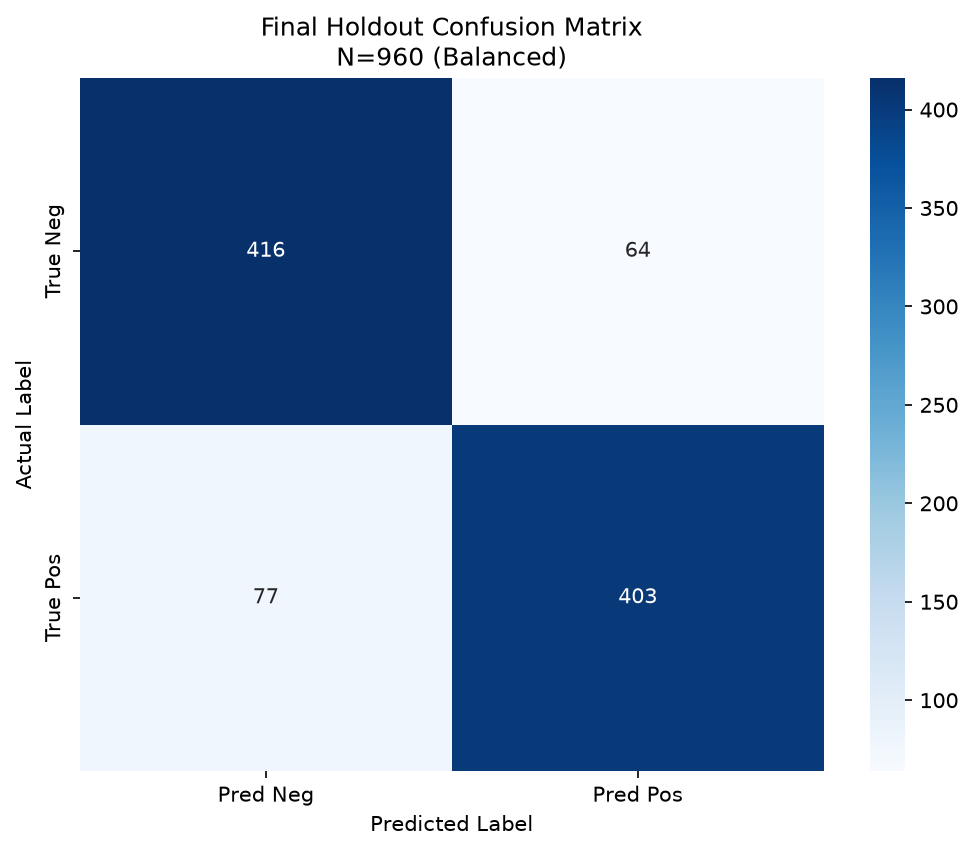

### Confidence Distribution: Correct vs Incorrect Predictions

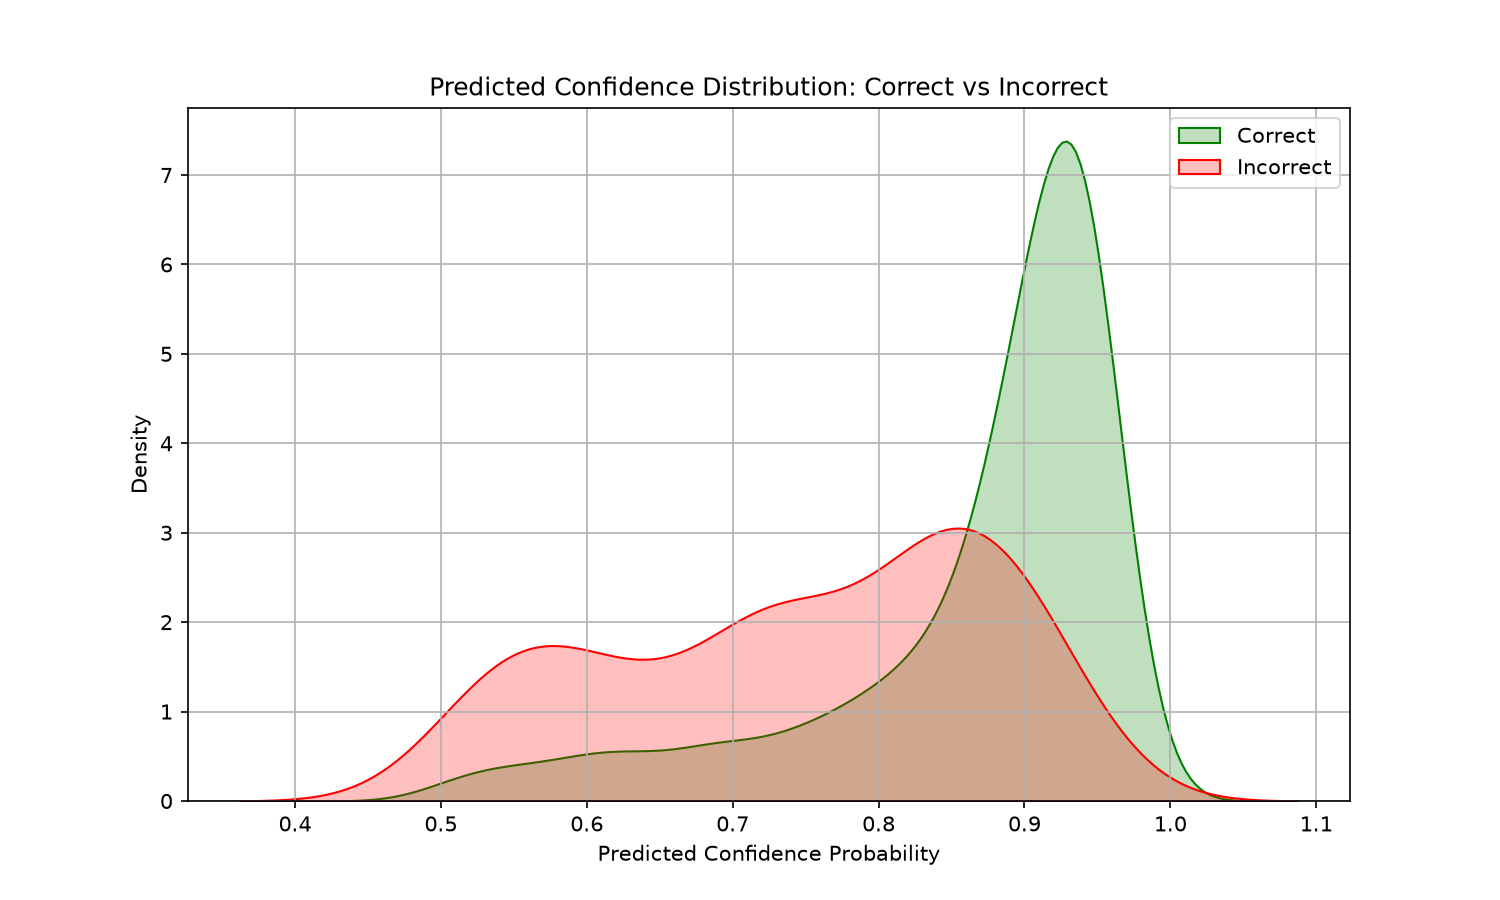

In [13]:
show_fig(
    "final_holdout_confusion_matrix.png",
    "Final Holdout Confusion Matrix",
)

show_fig(
    "correct_vs_incorrect_confidence.png",
    "Confidence Distribution: Correct vs Incorrect Predictions",
)


In [14]:
errors_df = pd.read_csv(str(practice3_root / "docs" / "result" / "practice_3_v2_3" / "holdout_errors.csv"))
high_conf_df = pd.read_csv(str(practice3_root / "docs" / "result" / "practice_3_v2_3" / "high_confidence_holdout_errors.csv"))

display(Markdown("### Representative Errors"))
display(colored_table(errors_df[errors_df['predicted_label'] == 1].head(3)[['text', 'predicted_confidence']], "False Positives"))
display(colored_table(errors_df[errors_df['predicted_label'] == 0].head(3)[['text', 'predicted_confidence']], "False Negatives"))
display(colored_table(high_conf_df.head(3)[['text', 'true_label', 'predicted_label', 'predicted_confidence']], "High Confidence Errors (>= 0.90)"))


### Representative Errors

,text,predicted_confidence
56,"the director and her capable cast appear to be caught in a heady whirl of new age-inspired good intentions , but the spell they cast isn't the least bit mesmerizing .",0.534042
57,"even in the summertime , the most restless young audience deserves the dignity of an action hero motivated by something more than franchise possibilities .",0.887775
58,"occasionally loud and offensive , but more often , it simply lulls you into a gentle waking coma .",0.669806


,text,predicted_confidence
0,"its gross-out gags and colorful set pieces . . . are of course stultifyingly contrived and too stylized by half . still , it gets the job done -- a sleepy afternoon rental .",0.871332
1,""" cremaster 3 "" should come with the warning "" for serious film buffs only ! """,0.738189
2,"writer/director joe carnahan's grimy crime drama is a manual of precinct cliches , but it moves fast enough to cover its clunky dialogue and lapses in logic .",0.892979


,text,true_label,predicted_label,predicted_confidence
0,no screen fantasy-adventure in recent memory has the showmanship of clones' last 45 minutes .,1,0,0.909996
1,"strip it of all its excess debris , and you'd have a 90-minute , four-star movie . as it is , it's too long and unfocused .",1,0,0.914079
2,it's an often-cute film but either needs more substance to fill the time or some judicious editing .,1,0,0.915480


## Phase 12 - Custom Inference

Evaluate model inference behavior on custom edge-case sentences featuring negation, contrast, and subtle sentiment.


In [15]:
df_custom = pd.read_csv("../docs/result/practice_3_v2_3/custom_inference_results.csv")
display(colored_table(
    df_custom[["category", "text", "predicted_label_name", "confidence", "expected_label", "match_expected"]],
    "Custom Inference Results",
    boolean_columns=["match_expected"]
))


,category,text,predicted_label_name,confidence,expected_label,match_expected
0,CLEAR_POSITIVE,I absolutely loved this movie. The acting was excellent and the plot was engaging.,Positive,0.938902,1.000000,True
1,CLEAR_NEGATIVE,This movie was boring and a complete waste of time. I fell asleep halfway through.,Negative,0.937520,0.000000,True
2,NEGATION,"I did not dislike the movie, but I also wouldn't say I enjoyed it.",Negative,0.778834,nan,nan
3,MIXED_SENTIMENT,"The acting was great, but the story was incredibly disappointing and contrived.",Negative,0.931136,nan,nan
4,SUBTLE_POSITIVE,"It is not perfect, but I would gladly watch it again on a rainy afternoon.",Negative,0.546219,1.000000,False
5,SUBTLE_NEGATIVE,"The movie looks beautiful, although there is little else to recommend about it.",Positive,0.588850,0.000000,False
6,AMBIGUOUS,I really expected more from this film given the cast.,Negative,0.662252,nan,nan
7,CONTRAST,"The beginning was excruciatingly slow, but the ending made the whole movie completely worthwhile.",Positive,0.883904,1.000000,True
8,NEGATION,Not exactly what I was hoping for.,Negative,0.905025,0.000000,True


## Phase 13 - Save / Reload Verification

Verify checkpoint persistence integrity by confirming identical model weights and deterministic inference outputs after reload.


In [16]:
with open("../docs/result/practice_3_v2_3/save_reload_verification.json") as f: verif = json.load(f)
v_data = pd.DataFrame([
    {"Metric": "Parameter Mismatches", "Value": verif["parameter_mismatch_count"]},
    {"Metric": "Prediction Matches", "Value": f"{verif['prediction_match_count']} / {verif['sentences_compared']}"},
    {"Metric": "Probability Max Diff", "Value": verif["max_probability_difference"]},
])
display(colored_table(v_data, "Save / Reload Evidence"))


,Metric,Value
0,Parameter Mismatches,0
1,Prediction Matches,9 / 9
2,Probability Max Diff,0.000000
